https://www.kaggle.com/datasets/saugataroyarghya/resume-dataset

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from wordcloud import WordCloud

import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import re
import string

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
df = pd.read_csv("/content/resume_data.csv")
df.head()

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,﻿job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,NaN,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,[None],[None],"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000


In [ ]:
df.shape

(9544, 35)

In [ ]:
df.describe()

,matched_score
count,9544.000000
mean,0.660831
std,0.167040
min,0.000000
25%,0.583333
50%,0.683333
75%,0.793333
max,0.970000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9544 entries, 0 to 9543
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   address                              784 non-null    object 
 1   career_objective                     4740 non-null   object 
 2   skills                               9488 non-null   object 
 3   educational_institution_name         9460 non-null   object 
 4   degree_names                         9460 non-null   object 
 5   passing_years                        9460 non-null   object 
 6   educational_results                  9460 non-null   object 
 7   result_types                         9460 non-null   object 
 8   major_field_of_studies               9460 non-null   object 
 9   professional_company_names           9460 non-null   object 
 10  company_urls                         9460 non-null   object 
 11  start_dates                   

In [ ]:
# check the missing values
df.isnull().sum()

,0
address,8760
career_objective,4804
skills,56
educational_institution_name,84
degree_names,84
passing_years,84
educational_results,84
result_types,84
major_field_of_studies,84
professional_company_names,84


In [ ]:
# check the percentage of missing values
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values("Percentage", ascending=False)

,Missing,Percentage
languages,8844,92.665549
proficiency_levels,8844,92.665549
address,8760,91.785415
issue_dates,7536,78.960604
certification_skills,7536,78.960604
certification_providers,7536,78.960604
expiry_dates,7536,78.960604
online_links,7536,78.960604
extra_curricular_activity_types,6118,64.103101
extra_curricular_organization_links,6118,64.103101


In [ ]:
print(df.duplicated().sum())

0


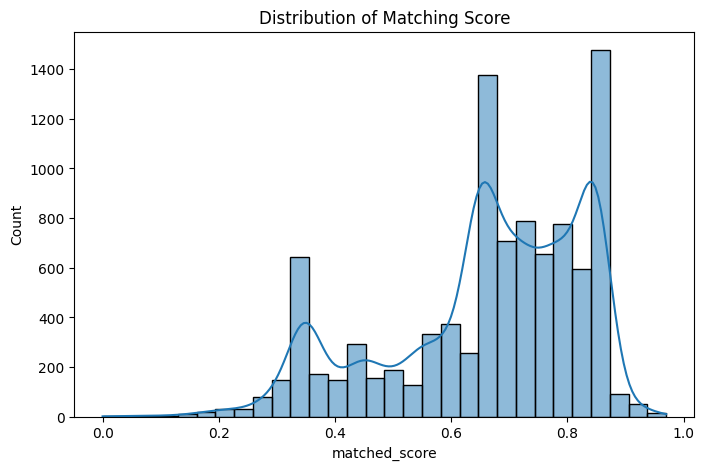

In [ ]:
# numerical distribution
plt.figure(figsize=(8,5))

sns.histplot(df["matched_score"], bins=30, kde=True)

plt.title("Distribution of Matching Score")

plt.show()

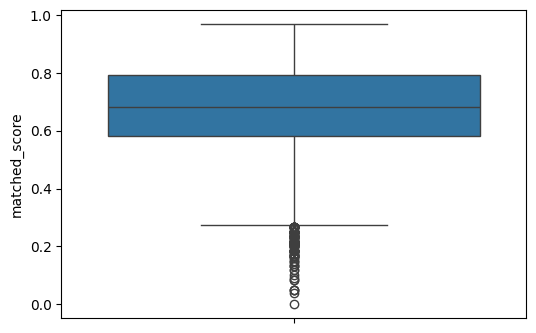

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df["matched_score"])

plt.show()

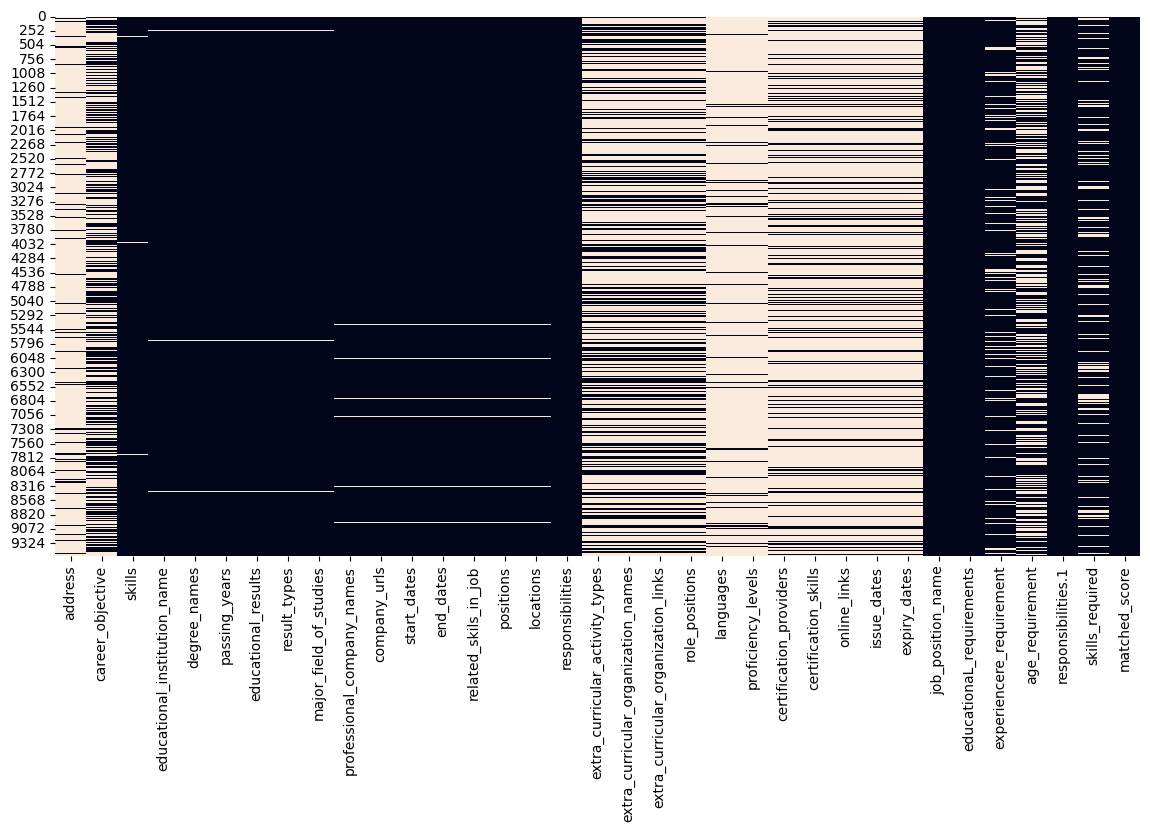

In [ ]:
plt.figure(figsize=(14,7))

sns.heatmap(df.isnull(), cbar=False)

plt.show()

In [ ]:
columns = [

'career_objective',

'skills',

'degree_names',

'major_field_of_studies',

'professional_company_names',

'positions',

'responsibilities',

'certification_skills',

'﻿job_position_name',

'educationaL_requirements',

'experiencere_requirement',

'responsibilities.1',

'skills_required',

'matched_score'

]

df = df[columns]

In [ ]:
df.fillna("", inplace=True)

In [ ]:
df.isnull().sum()

,0
career_objective,0
skills,0
degree_names,0
major_field_of_studies,0
professional_company_names,0
positions,0
responsibilities,0
certification_skills,0
﻿job_position_name,0
educationaL_requirements,0


In [ ]:
#Create Resume Text
df["resume_text"] = (

df["career_objective"] + " " +

df["skills"] + " " +

df["degree_names"] + " " +

df["major_field_of_studies"] + " " +

df["professional_company_names"] + " " +

df["positions"] + " " +

df["responsibilities"] + " " +

df["certification_skills"]

)

In [ ]:
#Create Job Description Text
df["job_text"] = (

df["﻿job_position_name"] + " " +

df["educationaL_requirements"] + " " +

df["experiencere_requirement"] + " " +

df["responsibilities.1"] + " " +

df["skills_required"]

)

In [ ]:
df["text"] = df["resume_text"] + " " + df["job_text"]

In [ ]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"\d+", "", text)

    text = re.sub(r"[^\w\s]", "", text)

    tokens = nltk.word_tokenize(text)

    tokens = [

        lemmatizer.lemmatize(word)

        for word in tokens

        if word not in stop_words

    ]

    return " ".join(tokens)

In [ ]:
nltk.download('punkt_tab')
df["clean_text"] = df["text"].apply(clean_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


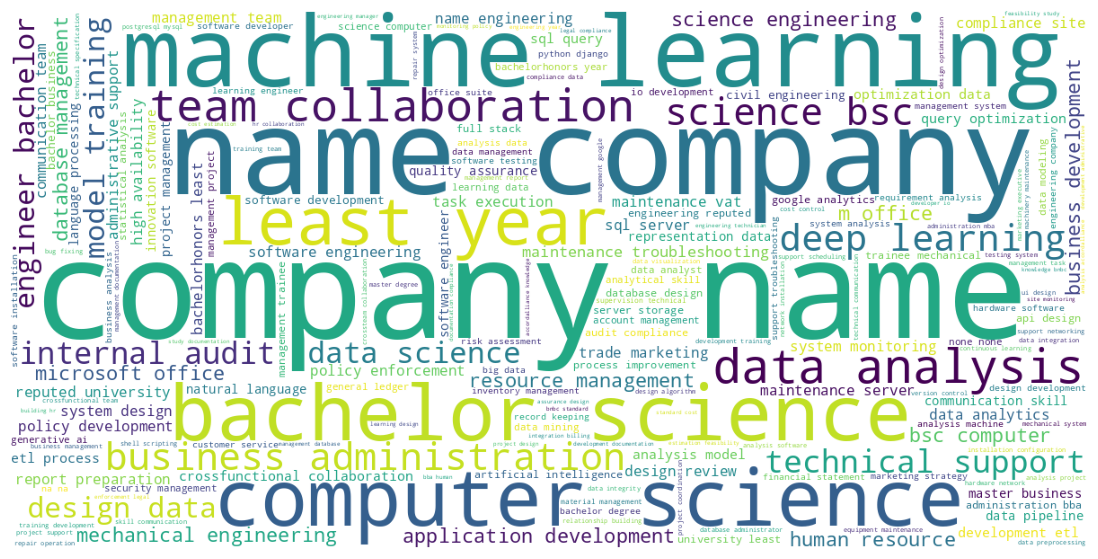

In [ ]:
text = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]

y = df["matched_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000)

X_train = tfidf.fit_transform(X_train)

X_test = tfidf.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error

from sklearn.metrics import mean_squared_error

from sklearn.metrics import r2_score

print("MAE :", mean_absolute_error(y_test,pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test,pred)))

print("R2 :", r2_score(y_test,pred))

MAE : 0.08957287448230856
RMSE : 0.11819229303834579
R2 : 0.4948389610287357


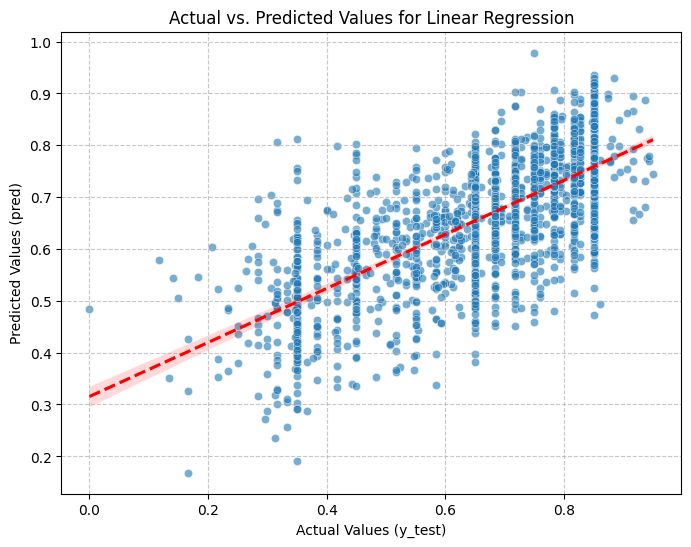

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=pred, alpha=0.6)
sns.regplot(x=y_test, y=pred, scatter=False, color='red', line_kws={'linestyle':'--'})
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (pred)')
plt.title('Actual vs. Predicted Values for Linear Regression')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This plot helps to visualize how well your model's predictions align with the actual values. The closer the points are to the red dashed line (representing `y = x`), the better your model's accuracy.

In [ ]:
# check the accuracy of model

In [ ]:
import joblib

joblib.dump(model,"resume_match_model.pkl")

joblib.dump(tfidf,"tfidf.pkl")

['tfidf.pkl']

In [ ]:
resume = """
Python
Machine Learning
Deep Learning
TensorFlow
SQL
Power BI
"""

job = """
Machine Learning Engineer

Python

TensorFlow

SQL

Docker

AWS
"""

text = clean_text(resume + " " + job)

vector = tfidf.transform([text])

score = model.predict(vector)

print(score)

[0.68089681]


In [ ]:
# =====================================
# Upload Resume File
# =====================================

from google.colab import files

uploaded = files.upload()

Saving Shan-Ali-Gen_AI_CV.pdf to Shan-Ali-Gen_AI_CV.pdf


In [ ]:
!pip install pdfplumber python-docx -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 74.0 MB/s eta 0:00:00


In [ ]:
import pdfplumber
import docx
import os

def extract_resume_text(file_path):

    if file_path.endswith(".pdf"):

        text = ""

        with pdfplumber.open(file_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"

        return text

    elif file_path.endswith(".docx"):

        document = docx.Document(file_path)

        text = "\n".join([para.text for para in document.paragraphs])

        return text

    else:
        raise ValueError("Only PDF and DOCX files are supported.")

In [ ]:
filename = list(uploaded.keys())[0]

resume_text = extract_resume_text(filename)

print("Resume Loaded Successfully")

print("-"*60)

print(resume_text[:1000])

Resume Loaded Successfully
------------------------------------------------------------
Shan Ali Data Scientist & Generative AI (LLM) Engineer
shanaliqadri890@gmail.com 03074792107 2000/08/20 linkedin.com/in/shan-ali-3a2528350
https://github.com/Mehar-shan https://www.kaggle.com/meharshanali
Profile Certificates and Experience
Data Scientist and Generative AI & LLM Engineer pursuing an Data Science Intern from VisaBridge
MS in Data Science from ITU, with strong expertise in data Worked on real-world datasets involving data preprocessing, feature
extraction, preprocessing, feature engineering, and model engineering, and exploratory analysis. Assisted in building and
training. Experienced in applying machine learning models evaluating machine learning models to support data-driven decision-
including logistic regression, decision trees, random forest, and making.
support vector machines, as well as artificial neural networks
(ANN) for real-world problems such as predictive analytics and 

In [ ]:
job_description = """
Machine Learning Engineer

Responsibilities

Develop ML models

Deploy AI solutions

Required Skills

Python
TensorFlow
SQL
Docker
AWS
Machine Learning
Deep Learning
"""

In [ ]:
# ==========================
# Predict ATS Score
# ==========================

combined = clean_text(resume_text + " " + job_description)

vector = tfidf.transform([combined])

prediction = model.predict(vector)[0]

prediction = max(0, min(1, prediction))

print("="*50)
print(f"Resume Match Score : {prediction:.2%}")
print("="*50)

Resume Match Score : 77.14%


In [ ]:
import re

def extract_skills(text):

    words = re.findall(r"[A-Za-z\+\#\.]{2,}", text.lower())

    return set(words)

resume_skills = extract_skills(resume_text)

job_skills = extract_skills(job_description)

matched = sorted(resume_skills.intersection(job_skills))

missing = sorted(job_skills - resume_skills)

print("Matched Skills")
print("-"*40)

for skill in matched:
    print("✔", skill)

print("\nMissing Skills")
print("-"*40)

for skill in missing:
    print("✘", skill)

Matched Skills
----------------------------------------
✔ ai
✔ deep
✔ engineer
✔ learning
✔ machine
✔ ml
✔ models
✔ python
✔ skills
✔ tensorflow

Missing Skills
----------------------------------------
✘ aws
✘ deploy
✘ develop
✘ docker
✘ required
✘ responsibilities
✘ solutions
✘ sql


In [ ]:
print("="*60)
print("Resume Improvement Suggestions")
print("="*60)

if len(missing) == 0:
    print("Excellent! Your resume already contains all major skills.")
else:

    print("\nConsider adding these skills if you have experience with them:\n")

    for skill in missing:
        print(f"• {skill}")

Resume Improvement Suggestions

Consider adding these skills if you have experience with them:

• aws
• deploy
• develop
• docker
• required
• responsibilities
• solutions
• sql


In [ ]:
print("="*60)
print("AI Resume Screening Report")
print("="*60)

print(f"Overall Match Score : {prediction:.2%}")

print(f"Matched Skills      : {len(matched)}")

print(f"Missing Skills      : {len(missing)}")

print("\nRecommendation:")

if prediction >= 0.85:
    print("★★★★★ Excellent Match")
    print("You are highly suitable for this role.")

elif prediction >= 0.70:
    print("★★★★☆ Good Match")
    print("Your profile is strong but could be improved.")

elif prediction >= 0.50:
    print("★★★☆☆ Average Match")
    print("Improve your resume by adding relevant projects and skills.")

else:
    print("★★☆☆☆ Low Match")
    print("Your resume requires significant improvements before applying.")

AI Resume Screening Report
Overall Match Score : 77.14%
Matched Skills      : 10
Missing Skills      : 8

Recommendation:
★★★★☆ Good Match
Your profile is strong but could be improved.
